In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('final_chess.csv',index_col =[0])
df

C:\Users\miche\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
1,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
2,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
3,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
4,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
...,...,...,...,...,...,...,...
3691276,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3691277,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3691278,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3691279,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


In [27]:
df.describe()

,MOVES,ALGEBRIC,WHITE,BLACK,RESULT,DATE
count,152978,152978,152978,152978,152978,152978
unique,103295,103300,3551,3739,4,4920
top,['d2d4'],['d4'],"Gligoric, Svetozar","Gligoric, Svetozar",1/2-1/2,1968.??.??
freq,112,112,1449,1426,61408,9956


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3691281 entries, 0 to 3691280
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   WHITE   object 
 1   BLACK   object 
 2   RESULT  object 
 3   DATE    object 
 4   MOVES   object 
 5   B_ELO   float64
 6   W_ELO   float64
dtypes: float64(2), object(5)
memory usage: 225.3+ MB


Removing missing values in the MOVES column

In [3]:
df = df[df['MOVES'].notna()]

In [4]:
df

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
3,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
4,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
5,"Solomon, Stephen J","Sarapu, Ortvin",0-1,0021.01.21,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",NaN,2461.0
6,"Heinemann, T..","Krauss, Jo",1/2-1/2,0031.12.29,"['e4', 'd6', 'd4', 'Nf6', 'Nc3', 'g6', 'Be3', ...",2154.0,2320.0
...,...,...,...,...,...,...,...
3691276,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3691277,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3691278,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3691279,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


The column is converted to a list, since we need to work only on moves. Using a regex expression all the moves with a check
are collected and store in a list

In [5]:
alg = df['MOVES'].to_list()

In [6]:
pattern = r'(\w+\+)'

In [7]:
checks = []

In [8]:
for s in alg:
    res= re.findall(pattern,s)
    
    if len(res) == 1:
        checks.append(res[0])
    elif len(res) > 0:
        for i in range(len(res)):
            checks.append(res[i])
           
    

In [40]:
len(checks)

13962661

Representing a chessboard with a dictionary. Each square has a counter updated every time a check happened in that square

In [41]:
chess_board = {'a1': 0,'a2': 0,'a3': 0,'a4': 0,'a5': 0,'a6': 0,'a7': 0,'a8': 0,
        'b1': 0,'b2': 0,'b3': 0,'b4': 0,'b5': 0,'b6': 0,'b7': 0,'b8': 0,
        'c1': 0,'c2': 0,'c3': 0,'c4': 0,'c5': 0,'c6': 0,'c7': 0,'c8': 0,
        'd1': 0,'d2': 0,'d3': 0,'d4': 0,'d5': 0,'d6': 0,'d7': 0,'d8': 0,
        'e1': 0,'e2': 0,'e3': 0,'e4': 0,'e5': 0,'e6': 0,'e7': 0,'e8': 0,
        'f1': 0,'f2': 0,'f3': 0,'f4': 0,'f5': 0,'f6': 0,'f7': 0,'f8': 0,
        'g1': 0,'g2': 0,'g3': 0,'g4': 0,'g5': 0,'g6': 0,'g7': 0,'g8': 0,
        'h1': 0,'h2': 0,'h3': 0,'h4': 0,'h5': 0,'h6': 0,'h7': 0,'h8': 0}

Update squares counter values

In [47]:
for c in checks:
    ind = c.index('+')
    
    try:
        if '=' not in c and '-' not in c:
            key = c[ind-2] + c[ind-1]
            chess_board[key] = chess_board[key] + 1
    except:
        continue
    

Converting the dictionary to a matrix

In [49]:
data = np.array(list(chess_board.values()) ).reshape(8,8) # transform to 2D
data = data.transpose() # transpose (swap rows with columns)
data = np.flipud(data)  # flip vertically to match chessboard layout
data

array([[110547, 129986, 211041, 340619, 271423, 199154, 123806, 107319],
       [120545, 149290, 179788, 255629, 287461, 309097, 193782, 192932],
       [ 92789, 154777, 205839, 255558, 332353, 476150, 248818, 208927],
       [137690, 250761, 242963, 302897, 316045, 290066, 300173, 188885],
       [131992, 248868, 218022, 342578, 302481, 291632, 265061, 184039],
       [101621, 143782, 315588, 222607, 285287, 345421, 223595, 164172],
       [113168, 147325, 177588, 245703, 246767, 249691, 167437, 141750],
       [115924, 127444, 202575, 309124, 278567, 192304, 119533,  90424]])

Create the heatmap

<AxesSubplot:>

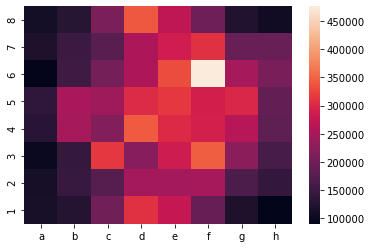

In [52]:
x_axis_labels = ['a','b','c','d','e','f','g','h'] # labels for x-axis
y_axis_labels = [8,7,6,5,4,3,2,1] # labels for y-axis
my_map = sns.heatmap(data, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
fig = my_map.get_figure()
fig.savefig("heatmap.png") 
my_map
